In [6]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

from omegaconf import OmegaConf
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download

from virtues.modules.multiplex_virtues import MultiplexVirtues
from virtues.modules.segmentation.unet import VirtuesSegmentationHead
from virtues.utils.utils import load_marker_embeddings, load_marker_embedding_dict
from virtues.utils.segmentation import remove_small_cells, assign_cell_types
from virtues.utils.plotting import plot_mask, CELL_PALETTE

from instanseg.utils.loss.instanseg_loss import InstanSeg as InstanceProcessor

from spora_io import MultiplexImagingDataset

# Pan-optic cell segmentation
In this notebook, we demonstrate how to use VirTues in combination with a U-Net style segmentation head to do both instance and phenotype-segmentation in one shot.

## 1. Model Initialization

To get started, instantiate the VirTues model and load its pretrained weights.

A default configuration file is provided at `configs/base_config.yaml`. This file contains all parameters required for the released VirTues model.

In addition, you must specify a directory containing the embeddings for all markers used. Each embedding should be saved as a `.pt` file, named according to its respective UniProt ID.

In [7]:
conf = OmegaConf.load('../configs/base_config.yaml')

PATH_MARKER_EMBEDDINGS = '../assets/example_dataset/marker_embeddings'

In [8]:
marker_embeddings = load_marker_embeddings(PATH_MARKER_EMBEDDINGS)
marker_embedding_dict = load_marker_embedding_dict(PATH_MARKER_EMBEDDINGS) # dictionary mapping uniport ids to the index of the corresponding embedding in marker_embeddings

model = MultiplexVirtues(
    use_default_config = False,
    custom_config = None,
    prior_bias_embeddings=marker_embeddings,
    prior_bias_embedding_type='esm',
    prior_bias_embedding_fusion_type='add',
    patch_size=conf.model.patch_size,
    model_dim=conf.model.model_dim,
    feedforward_dim=conf.model.feedforward_dim,
    encoder_pattern=conf.model.encoder_pattern,
    num_encoder_heads=conf.model.num_encoder_heads,
    decoder_pattern=conf.model.decoder_pattern,
    num_decoder_heads=conf.model.num_decoder_heads,
    num_hidden_layers=conf.model.num_decoder_hidden_layers,
    positional_embedding_type=conf.model.positional_embedding_type,
    dropout=conf.model.dropout,
    group_layers=conf.model.group_layers,
    norm_after_encoder_decoder=conf.model.norm_after_encoder_decoder,
    verbose=False
)

We provide model weights of our pretrained VirTues instance on Hugging Face Hub. These can be downloaded via `hf_hub_download` as follows.

In [9]:
CACHE_DIR = '../assets/checkpoints'
hf_hub_download(repo_id='bunnelab/virtues', filename='virtues-sp32/model.safetensors', local_dir=CACHE_DIR)

weights = load_file(os.path.join(CACHE_DIR, 'virtues-sp32/model.safetensors'), device='cuda')
model.load_state_dict(weights)

model = model.cuda().eval()

Please refer to the *Model Zoo* in the `README.md` for a list of all available model weights including licences.

Next, we initialize and load the VirTues segmentation head:

In [10]:
segmentation_model = VirtuesSegmentationHead(
    virtues_model=model,
    dim_out=5,
    num_celltypes=9,
).cuda().eval()

In [11]:
hf_hub_download(repo_id='bunnelab/virtues', filename='virtues-sp32/segmentation-head.safetensors', local_dir=CACHE_DIR)
state = load_file(os.path.join(CACHE_DIR, 'virtues-sp32/segmentation-head.safetensors'), device='cuda')

segmentation_model.load_state_dict(state, strict=False)

_IncompatibleKeys(missing_keys=['virtues_model.encoder.patch_summary_token', 'virtues_model.encoder.masked_token', 'virtues_model.encoder.patch_encoder.weight', 'virtues_model.encoder.patch_encoder.bias', 'virtues_model.encoder.prior_embedding_encoder.weight', 'virtues_model.encoder.prior_embedding_encoder.bias', 'virtues_model.encoder.layer_norm.weight', 'virtues_model.encoder.layer_norm.bias', 'virtues_model.encoder.encoder.0.encoder_layer.multi_head_attention.W_q.weight', 'virtues_model.encoder.encoder.0.encoder_layer.multi_head_attention.W_q.bias', 'virtues_model.encoder.encoder.0.encoder_layer.multi_head_attention.W_k.weight', 'virtues_model.encoder.encoder.0.encoder_layer.multi_head_attention.W_k.bias', 'virtues_model.encoder.encoder.0.encoder_layer.multi_head_attention.W_v.weight', 'virtues_model.encoder.encoder.0.encoder_layer.multi_head_attention.W_v.bias', 'virtues_model.encoder.encoder.0.encoder_layer.multi_head_attention.W_o.weight', 'virtues_model.encoder.encoder.0.encoder

## 2. Dataset Initialization
Next, we instantiate our dataset. For this we use the data loading library [**spora-io**](https://github.com/bunnelab/spora-io) that is part of the spatial proteomics ecosystem [spora](spora.epfl.ch). 
spora-io requires each dataset to be formatted in the standardized format of [spora-data](https://spora.epfl.ch/docs-data.html#structure).

We provide a simple example dataset following this format at `assets/example_dataset` consisting out of a single tissue image
We can access this dataset using the class `MultiplexImagingDataset`.

In [12]:
ds_conf = OmegaConf.load('../configs/datasets/example_config.yaml')['datasets']['example_dataset']

dataset = MultiplexImagingDataset(
        name=ds_conf.name,
        path=os.path.join('..', ds_conf.path),
        modality=ds_conf.modality,
        standardization=ds_conf.standardization,
        resolution=ds_conf.resolution,
        tile_size=conf.data.tile_size,
        disable_quantile_mask=True,
        filter_list=['gaussian_blur',],
        use_mean_std=True,
)

2026-06-22 14:51:00.444 | WARNING  | spora_io.utils.utils:print_verbose:28 - No tile strategy provided, using default.
2026-06-22 14:51:00.477 | INFO     | spora_io.utils.utils:print_verbose:26 - Using image-channel map from ../assets/example_dataset/imc/channels_per_tissue.parquet
2026-06-22 14:51:00.490 | INFO     | spora_io.utils.dataset.standardize:__init__:192 - Loaded standardization stats 'quantile_clipping_log1p/uq_0.99_image' from ../assets/example_dataset/imc/1_0mpp/standardization/quantile_clipping_log1p/uq_0.99_image (quantile_level=image, stats_level=global, use_mean_std=True)
2026-06-22 14:51:00.490 | INFO     | spora_io.utils.utils:print_verbose:26 - Using Multiplex standardization: QuantileClippingLog1PStandardizer
2026-06-22 14:51:00.491 | INFO     | spora_io.utils.utils:print_verbose:26 - Uniprot mask created with 40 channels.
2026-06-22 14:51:00.495 | INFO     | spora_io.utils.utils:print_verbose:26 - Loaded tile coordinates from ../assets/example_dataset/tiling/1_0m

Filters to apply: ['gaussian_blur']


Using this dataset class, we can load a tissue using the `get_tissue` function. The argument `kind=uniprot_filtered` indicates that the image should be filtered for channels that passed quality control and have been assigned a Uniprot ID.

The returned tissue object stores both the image array as well as list of Uniprot IDs identifying each channel. We map these Uniprot IDs the the corresponding marker embedding indices.

In [13]:
tissue_id = 'cords2024cancer_ocmzljpb_0001'

tissue = dataset.get_tissue(tissue_id=tissue_id, kind='uniprot_filtered')
x = tissue.image
uniprot_ids = tissue.uniprot_ids
midxs = torch.tensor([marker_embedding_dict[uid] for uid in uniprot_ids], dtype=torch.long)

crop = x[:, 200:328, 200:328]

crop = crop.cuda()
midxs = midxs.cuda()

## 3. Tile-level segmentation

We can perform both instance and cell type segmentation on a single crop using the function `VirtuesSegmentationHead.segment_tile(multiplex, channel_ids)`.
This function returns two tensors:
1. `pred_instance`, a integer mask of shape `(H,W)` containing the cell ids of the segmented cell instances and
2. `semantic_logits` a logit mask of shape `(num_classes, H, W)` containing pixel-wise cell type logits.

**Note 1:** This function requires an input crop of fixed size $128 \times 128$ (the training crop size of VirTues as well as the segmentation head).

**Note 2:** Segmentation performs best when at least one nucleus marker, e.g. Histone H3, has been measured. 

In [14]:
pred_instance, semantic_logits = segmentation_model.segment_tile(crop, midxs)
pred_instance.shape, semantic_logits.shape

(torch.Size([128, 128]), torch.Size([9, 128, 128]))

Next, we apply several post-processing steps:
1. From the instance segmentation mask, we filter out cells below a minimum area threshold.
2. We convert the class logits to class predictions using `argmax`, manually suppressing `None` and `Unknown` cell types.
3. We merge the pixel-wise cell type mask with the cell instance mask to obtain a per-cell type assignment using the utility function `assign_cell_types`.

Here, we use the class index to cell type mapping:
```python
{
    0: 'None',
    1: 'B cell',
    2: 'CD4 T cell',
    3: 'CD8 T cell',
    4: 'Fibroblasts /Stroma',
    5: 'Myeloid',
    6: 'Tumor',
    7: 'Unknown',
    8: 'Vessel / Endo.'
 }
 ```

In [15]:
pred_instance = pred_instance.cpu()
pred_instance = remove_small_cells(pred_instance, min_cell_size=15)

cell_type_mapping = {0: 'None', 1: 'B cell', 2: 'CD4 T cell', 3: 'CD8 T cell', 4: 'Fibroblasts /Stroma', 5: 'Myeloid', 6: 'Tumor', 7: 'Unknown', 8: 'Vessel / Endo.'}
reverse_cell_type_mapping = {v: k for k, v in cell_type_mapping.items()}

surpressed_cell_types = ['None', 'Unknown']
surpressed_cell_type_ids = [reverse_cell_type_mapping[ct] for ct in surpressed_cell_types]

semantic_logits[surpressed_cell_type_ids, :, :] = float('-inf')
semantic_pred = torch.argmax(semantic_logits, dim=0)
semantic_pred = semantic_pred.cpu()

semantic_pred = assign_cell_types(pred_instance, semantic_pred)

Let us visualize the predicted instance and phenotype cell segmentations:

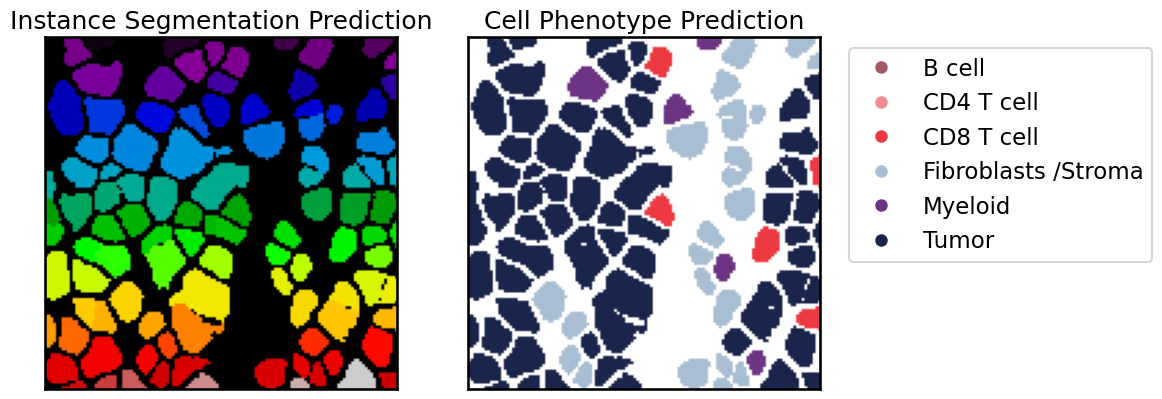

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(pred_instance, cmap="nipy_spectral")
ax[0].set_title("Instance Segmentation Prediction")

plot_mask(semantic_pred, id_to_name=cell_type_mapping, name_to_color=CELL_PALETTE, ax=ax[1],)
ax[1].set_title("Cell Phenotype Prediction")

handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'{cell_type_mapping[i]}', markerfacecolor=CELL_PALETTE[cell_type_mapping[i]], markersize=10) for i in range(1, semantic_pred.max() + 1)]
ax[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

for a in ax.flatten():
    a.set_xticks([])
    a.set_yticks([])

plt.show()

## 4. Tissue-wide segmentation

In most cases, we do not only want to segment a single crop but a full tissue at once. For this, we can use VirTues' segmentation head in a sliding window approach and stitch the predicted logits together.
We provide a utility function for this with `VirtuesSegmentationHead.segment_tissue`.

In [17]:
pred_instance, semantic_logits = segmentation_model.segment_tissue(x.cuda(), midxs, tile_size=128, overlap=32, batch_size=4)
pred_instance.shape, semantic_logits.shape

(torch.Size([697, 597]), torch.Size([9, 697, 597]))

Again, we apply the same post-processing steps as above to the tissue-level predictions.

In [18]:
pred_instance = pred_instance.cpu()
pred_instance = remove_small_cells(pred_instance, min_cell_size=15)

cell_type_mapping = {0: 'None', 1: 'B cell', 2: 'CD4 T cell', 3: 'CD8 T cell', 4: 'Fibroblasts /Stroma', 5: 'Myeloid', 6: 'Tumor', 7: 'Unknown', 8: 'Vessel / Endo.'}
reverse_cell_type_mapping = {v: k for k, v in cell_type_mapping.items()}

surpressed_cell_types = ['None', 'Unknown']
surpressed_cell_type_ids = [reverse_cell_type_mapping[ct] for ct in surpressed_cell_types]

semantic_logits[surpressed_cell_type_ids, :, :] = float('-inf')
semantic_pred = torch.argmax(semantic_logits, dim=0)
semantic_pred = semantic_pred.cpu()

semantic_pred = assign_cell_types(pred_instance, semantic_pred)

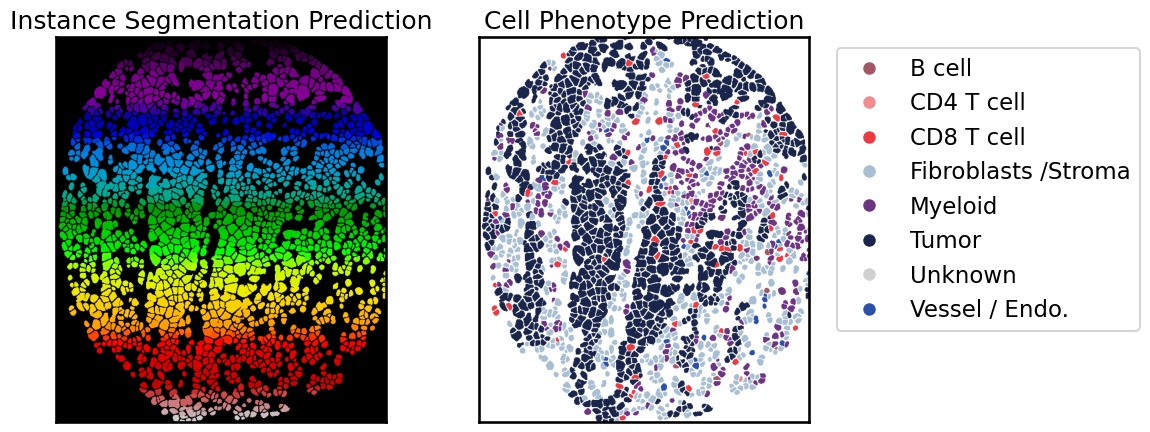

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(pred_instance, cmap="nipy_spectral")
ax[0].set_title("Instance Segmentation Prediction")

plot_mask(semantic_pred, id_to_name=cell_type_mapping, name_to_color=CELL_PALETTE, ax=ax[1],)
ax[1].set_title("Cell Phenotype Prediction")

handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'{cell_type_mapping[i]}', markerfacecolor=CELL_PALETTE[cell_type_mapping[i]], markersize=10) for i in range(1, semantic_pred.max() + 1)]
ax[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

for a in ax.flatten():
    a.set_xticks([])
    a.set_yticks([])

plt.show()